In [1]:
import matplotlib.pyplot as plt
from astropy.io import fits
import pandas as pd
import numpy as np
import warnings
import glob
import os 

from pysme.synthesize import synthesize_spectrum
from pysme.linelist.vald import ValdFile
from pysme.synthesize import Synthesizer
from pysme.sme import SME_Structure
from pysme.solve import solve
from pysme.abund import Abund
from pysme import util

warnings.filterwarnings('ignore')
plt.rcParams['text.usetex'] = True
%matplotlib inline

util.start_logging('../pySME_tutorial/log.log', level='INFO', )

/Users/felipe.gran/miniforge3/envs/pysme/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
os.chdir('../pySME_tutorial/')

## Easy case: generate a synthetic

In [3]:
sme = SME_Structure()
sme.teff, sme.logg, sme.monh = 5700, 4.4, 0
sme.abund = Abund.solar()
sme.wran = [6436, 6444] # sme.wave = np.arange(6436, 6444, 0.1)

In [4]:
vald = ValdFile('sun.lin')
ll = pd.DataFrame(vald)
sme.linelist = vald

INFO - Loading VALD file sun.lin


In [5]:
sme = synthesize_spectrum(sme)

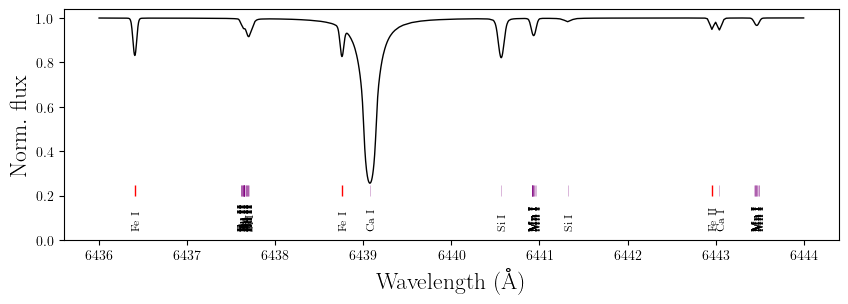

In [6]:
plt.figure(figsize=(10,3))

plt.plot(sme.wave[0], sme.synth[0], color='k', lw=1)

for i, line in ll.iterrows():
    color, alpha, lw = 'purple', 0.4, 0.5
    if 'Fe' in line.species:
        color, alpha, lw = 'r', 1., 1
    plt.vlines(x=line.wlcent, ymin=0.2, ymax=0.25, color=color, alpha=alpha, lw=lw)
    plt.annotate(text=r'${\rm %s}$' %line.species.replace(' ', '\ ').replace('1', 'I').replace('2', 'II'), xy=(line.wlcent-0.04, 0.05), rotation=90, fontsize=8)

plt.xlabel(r'${\rm Wavelength\ (\AA)}$', size=17)
plt.ylabel(r'${\rm Norm.\ flux}$', size=17)
plt.ylim(0, )
plt.show()

## Easy case II: change the synthetic

In [7]:
sme = SME_Structure()
sme.teff, sme.logg, sme.monh = 5700, 4.4, 0
sme.abund = Abund.solar()
sme.wran = [6436, 6444] # sme.wave = np.arange(6436, 6444, 0.1)

In [8]:
vald = ValdFile('sun.lin')
ll = pd.DataFrame(vald)
sme.linelist = vald

INFO - Loading VALD file sun.lin


In [9]:
solar_Si = sme.abund.get_element('Si')

sme.abund.update_pattern({'Si': solar_Si + 0.5})
# sme.abund.update_pattern({'Si': solar_Si + 0.5, 'Fe': 7.5})

In [10]:
sme = synthesize_spectrum(sme)

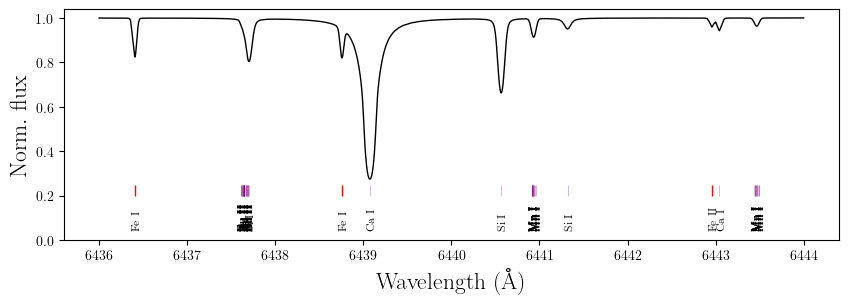

In [11]:
plt.figure(figsize=(10,3))

plt.plot(sme.wave[0], sme.synth[0], color='k', lw=1)

for i, line in ll.iterrows():
    color, alpha, lw = 'purple', 0.4, 0.5
    if 'Fe' in line.species:
        color, alpha, lw = 'r', 1., 1
    plt.vlines(x=line.wlcent, ymin=0.2, ymax=0.25, color=color, alpha=alpha, lw=lw)
    plt.annotate(text=r'${\rm %s}$' %line.species.replace(' ', '\ ').replace('1', 'I').replace('2', 'II'), xy=(line.wlcent-0.04, 0.05), rotation=90, fontsize=8)

plt.xlabel(r'${\rm Wavelength\ (\AA)}$', size=17)
plt.ylabel(r'${\rm Norm.\ flux}$', size=17)
plt.ylim(0, )
plt.show()

## Medium case I: fit a real world spectrum

In [3]:
solar = SME_Structure()
solar.abund.set_pattern_by_name('asplund2009')

In [4]:
def pix_to_wl(header, pix): #Return wl in AA
    return 10. * (header['CRVAL1'] + (np.arange(pix) - header['CRPIX1']) * header['CDELT1'])

In [5]:
spec = fits.open('red1_ADP.2023-06-09T13_39_14.777.fits')
wl = pix_to_wl(spec[0].header, spec[0].header['NAXIS1'])
spec, uncs = spec[0].data, 1./spec[0].data

In [6]:
sme = SME_Structure()

sme.ipres = 42000
sme.wave = wl
sme.spec = spec
sme.uncs = uncs

sme.abund = Abund.solar()
sme.teff, sme.logg, sme.monh, sme.vmic = 4800, 1.5, -3.0, 1.5
sme.wran = [5100, 5200]

WARNING - The wavelength range is overriden by the existing wavelength grid


In [7]:
sme.atmo.source = 'marcs2012.sav'
synthesizer = Synthesizer()
synthesizer.get_atmosphere(sme).atmo

Atmosphere(teff=4800.0,
logg=1.5000000000000002,
abund= [M/H]=-3.000 applied to abundance pattern. Values below are abundances.
  H      He     Li     Be     B      C      N      O      F      Ne     Na   
 12.000 12.113 -4.955 -4.625 -3.305  2.385  1.775  3.055 -1.445  2.235  0.165
  Mg     Al     Si     P      S      Cl     Ar     K      Ca     Sc     Ti   
  1.925  0.365  1.905 -0.645  1.535 -0.505  0.575 -0.925  0.705 -2.835 -0.705
  V      Cr     Mn     Fe     Co     Ni     Cu     Zn     Ga     Ge     As   
 -2.005 -0.365 -0.615  1.445 -1.085  0.225 -1.795 -1.405 -3.125 -2.425 -3.715
  Se     Br     Kr     Rb     Sr     Y      Zr     Nb     Mo     Tc     Ru   
 -2.675 -3.445 -2.755 -3.405 -3.085 -3.795 -3.425 -4.585 -4.085-10.965 -4.165
  Rh     Pd     Ag     Cd     In     Sn     Sb     Te     I      Xe     Cs   
 -4.885 -4.345 -5.065 -4.235 -4.405 -4.005 -5.005 -3.815 -4.495 -3.765 -4.935
  Ba     La     Ce     Pr     Nd     Pm     Sm     Eu     Gd     Tb     Dy   
 -3.835 -4.875

In [8]:
vald = ValdFile('linelist.lin')
ll = pd.DataFrame(vald)

INFO - Loading VALD file linelist.lin


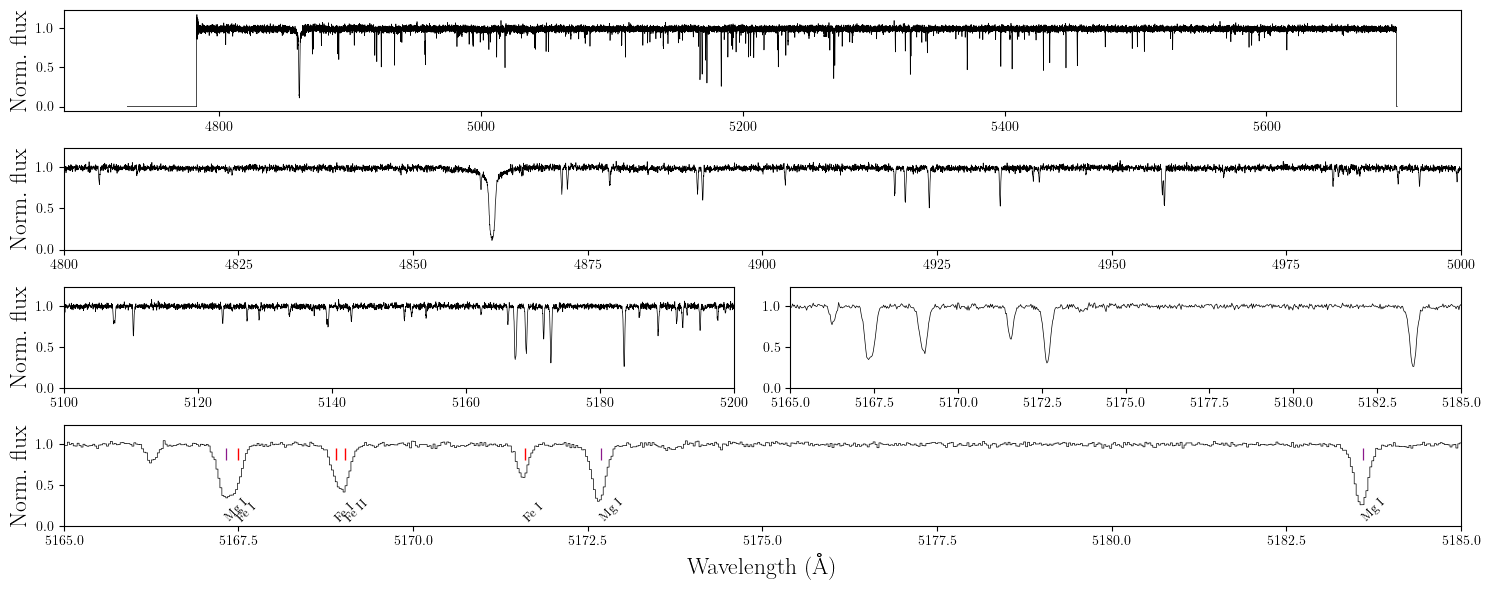

In [9]:
plt.figure(figsize=(15,6))

plt.subplot(4,1,1)
plt.plot(sme.wave.data, sme.spec.data, color='k', lw=0.5)
plt.ylabel(r'${\rm Norm.\ flux}$', size=17)

plt.subplot(4,1,2)
plt.plot(sme.wave.data, sme.spec.data, color='k', lw=0.5)
plt.ylabel(r'${\rm Norm.\ flux}$', size=17)
plt.xlim(4800, 5000)
plt.ylim(0, )

plt.subplot(4,2,5)
plt.plot(sme.wave.data, sme.spec.data, color='k', lw=0.5)
plt.ylabel(r'${\rm Norm.\ flux}$', size=17)
plt.xlim(5100, 5200)
plt.ylim(0, )

plt.subplot(4,2,6)
plt.plot(sme.wave.data, sme.spec.data, color='k', lw=0.5)
plt.xlim(5165, 5185)
plt.ylim(0, )

plt.subplot(4,1,4)
plt.step(sme.wave.data, sme.spec.data, color='k', lw=0.5, where='mid')
plt.xlim(5165, 5185)
plt.ylim(0, )

for i, line in ll.iterrows():
    if 5165 > line.wlcent > 5185: continue
    
    color, alpha, lw = 'purple', 0.9, 0.9
    if 'Fe' in line.species:
        color, alpha, lw = 'r', 1., 1
    plt.vlines(x=line.wlcent, ymin=0.8, ymax=0.95, color=color, alpha=alpha, lw=lw)
    plt.annotate(text=r'${\rm %s}$' %line.species.replace(' ', '\ ').replace('1', 'I').replace('2', 'II'), xy=(line.wlcent-0.04, 0.05), rotation=45, fontsize=9)

plt.xlabel(r'${\rm Wavelength\ (\AA)}$', size=17)
plt.ylabel(r'${\rm Norm.\ flux}$', size=17)

plt.tight_layout()
plt.show()

In [10]:
sme = SME_Structure()

sme.ipres = 42000
sme.spec = spec[(wl > 5165.) & (wl < 5185.)]
sme.uncs = uncs[(wl > 5165.) & (wl < 5185.)]
sme.wave = wl[(wl > 5165.) & (wl < 5185.)]
sme.linelist = vald[(vald.wlcent > 5165.) & (vald.wlcent < 5185.)]

sme.accft, sme.accgt, sme.accxt = 1e-8, 1e-8, 1e-8
sme.vrad_bounds = (-10., 10.)
sme.vrad_flag = 'whole'
sme.cscale_flag = 'linear'

# sme.nlte.set_nlte('Mg')
# sme.nlte.set_nlte('Fe')

sme.abund = Abund.solar()
sme.teff, sme.logg, sme.monh, sme.vmic, sme.vmac = 5120, 2.1, -2.6, 1.9, 6.5

In [11]:
%%time

fitparameters = ['teff', 'monh', 'vmic', 'vmac', 'abund Mg', 'abund Fe']
fitparameters = ['abund Mg', 'abund Fe']
sme = solve(sme, fitparameters)

INFO - Fitting Spectrum with Parameters: abund Mg,abund Fe
INFO - Synthesizing residual with values Abund mg=4.9300, Abund fe=4.8500
INFO - Synthesizing jacobian with values Abund mg=4.9400, Abund fe=4.8500
INFO - Synthesizing jacobian with values Abund mg=4.9300, Abund fe=4.8600
INFO -    Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
INFO -        0              1         1.6974e+00                                    1.85e-01    
INFO - Synthesizing residual with values Abund mg=7.4074, Abund fe=9.7800
WARNING - WARNING: EOS-computed electron density differs from the model by 425% in layer 1
INFO - Synthesizing jacobian with values Abund mg=7.4174, Abund fe=9.7800
WARNING - WARNING: EOS-computed electron density differs from the model by 425% in layer 1
INFO - Synthesizing jacobian with values Abund mg=7.4074, Abund fe=9.7900
WARNING - WARNING: EOS-computed electron density differs from the model by 436% in layer 1
INFO -        1             

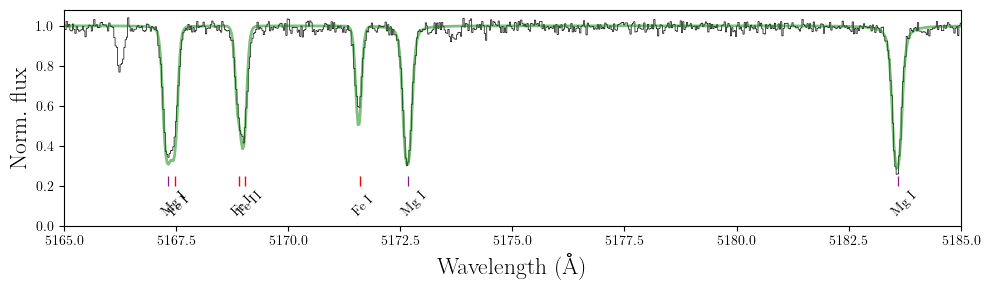

In [12]:
plt.figure(figsize=(10,3))

plt.step(sme.wave.data, sme.spec.data, color='k', lw=0.5, where='mid')
plt.plot(sme.wave.data, sme.synth.data, color='g', lw=2, alpha=0.5)
plt.xlim(5165, 5185)
plt.ylim(0, )

for i, line in ll.iterrows():
    if 5165 > line.wlcent > 5185: continue
    
    color, alpha, lw = 'purple', 0.9, 0.9
    if 'Fe' in line.species:
        color, alpha, lw = 'r', 1., 1
    plt.vlines(x=line.wlcent, ymin=0.2, ymax=0.25, color=color, alpha=alpha, lw=lw)
    plt.annotate(text=r'${\rm %s}$' %line.species.replace(' ', '\ ').replace('1', 'I').replace('2', 'II'), xy=(line.wlcent-0.2, 0.05), rotation=45, fontsize=10)

plt.xlabel(r'${\rm Wavelength\ (\AA)}$', size=17)
plt.ylabel(r'${\rm Norm.\ flux}$', size=17)

plt.tight_layout()
plt.show()

In [13]:
print('[Mg/Fe] = %2.2f +- %2.2f dex' %(sme.fitresults.values[0] - solar.abund.get_element('Mg'), sme.fitresults.fit_uncertainties[0]))
print()
print('[Fe/H] = %2.2f +- %2.2f dex' %(sme.fitresults.values[1] - solar.abund.get_element('Mg') + sme.monh, sme.fitresults.fit_uncertainties[0]))

[Mg/Fe] = 0.40 +- 0.03 dex

[Fe/H] = -2.59 +- 0.03 dex
